In [ ]:
# 0) Installs
!pip install -q transformers peft trl datasets accelerate bitsandbytes seaborn scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 38.7 MB/s eta 0:00:00


In [ ]:
# ============================================================
# PropInsight — QLoRA Finetune FIRST (no baseline)
# Splits must already exist in /content/drive/MyDrive/PropInsight/propinsight_datasets
# Saves adapters to models/finetuned and predictions to results/finetuned_predictions.json
# ============================================================


# 1) Imports & Drive
import os, json, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
from pathlib import Path
from tqdm.auto import tqdm
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, TrainingArguments, Trainer, EarlyStoppingCallback
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from google.colab import drive

drive.mount('/content/drive')

# 2) Paths (Path-only)
BASE = Path("/content/drive/MyDrive/PropInsight")

DATASETS_DIR = BASE / "propinsight_datasets"
TRAIN_JSON   = DATASETS_DIR / "train.json"
VAL_JSON     = DATASETS_DIR / "validation.json"
TEST_JSON  = DATASETS_DIR / "test.json"

# --- FASTER suffix outputs ---
MODELS_DIR            = BASE / "models"
FINETUNED_DIR         = MODELS_DIR / "finetuned_faster"    # <—
RESULTS_DIR           = BASE / "results"
VISUALIZATIONS_DIR    = BASE / "visualizations"
TENSORBOARD_LOGS      = RESULTS_DIR / "tensorboard"

TRAINING_CONFIG_FAST  = RESULTS_DIR / "training_config_faster.json"
FINETUNED_PRED_FAST   = RESULTS_DIR / "finetuned_predictions_faster.json"
EVAL_RESULTS_FAST     = RESULTS_DIR / "evaluation_results_faster.json"

for d in [MODELS_DIR, FINETUNED_DIR, RESULTS_DIR, VISUALIZATIONS_DIR, TENSORBOARD_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Dirs ready")
print(f"Splits present? train={TRAIN_JSON.exists()} val={VAL_JSON.exists()} test={TEST_JSON.exists()}")

# 3) Load existing splits
if not (TRAIN_JSON.exists() and VAL_JSON.exists() and TEST_JSON.exists()):
    raise FileNotFoundError("Missing splits. Ensure train/validation/test.json exist under propinsight_datasets.")

train_data = json.load(open(TRAIN_JSON, "r", encoding="utf-8"))
val_data   = json.load(open(VAL_JSON,   "r", encoding="utf-8"))
test_data  = json.load(open(TEST_JSON,  "r", encoding="utf-8"))
print(f"✓ Loaded: train={len(train_data)} | val={len(val_data)} | test={len(test_data)}")

# 4) QLoRA setup (AISG base IT model)
MODEL_ID = "aisingapore/Qwen-SEA-LION-v4-32B-IT"   # base model for QLoRA

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# 4-bit quant config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto", trust_remote_code=True
)
# Faster math
torch.backends.cuda.matmul.allow_tf32 = True
try: torch.set_float32_matmul_precision("high")
except: pass

# Gradient checkpointing (keep if you need memory; speed improves if you can disable)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

# --- LoRA FASTER (r=8, alpha=16) ---
lora_cfg = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# 5) Prompt building (teacher forcing via chat template)
SYSTEM_MSG = (
    "You are PropInsight, a Singapore real-estate expert. "
    "Return ONLY the Output block with fields: Overall Sentiment, Price Sentiment, "
    "Policy Sentiment, Affordability Sentiment, Location, Aspect, Entity, Policy Mentioned, "
    "Singlish Detected, Cultural Context, Emotion, Datetime, Source, Reasoning."
)

def sft_text(sample: dict) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {"role": "user",
         "content": f"{sample.get('instruction','Analyze the sentiment of this Singapore property comment:')}\n\n"
                    f"Input: {sample.get('input','')}\n\nReturn only the Output block."}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt + "\nOutput: " + sample.get("output","")

train_ds = Dataset.from_list([{"text": sft_text(x)} for x in train_data])
val_ds   = Dataset.from_list([{"text": sft_text(x)} for x in val_data])

# --- SHORTER SEQ: max_length=1024 ---
def tok_fn(batch):
    t = tokenizer(batch["text"], max_length=1024, truncation=True, padding="max_length")
    t["labels"] = t["input_ids"].copy()
    return t

train_ds = train_ds.map(tok_fn, batched=True, remove_columns=["text"])
val_ds   = val_ds.map(tok_fn,   batched=True, remove_columns=["text"])

# 6) TrainingArguments — FASTER preset
bf16_ok = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
args = TrainingArguments(
    output_dir=str(FINETUNED_DIR),

    # Effective batch ~ 16
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,

    # FEWER STEPS: cap total updates
    # num_train_epochs=None, # Removed this line
    max_steps=600,                 # <— stop after 600 steps

    learning_rate=2e-4,
    warmup_ratio=0.03,
    weight_decay=0.01,

    # CUT EVAL/CHECKPOINT OVERHEAD — per-epoch only
    eval_strategy="epoch",   # <—
    save_strategy="epoch",         # <—
    save_total_limit=2,

    logging_steps=10,
    logging_dir=str(TENSORBOARD_LOGS),
    report_to=["tensorboard"],

    bf16=bf16_ok,
    fp16=not bf16_ok,

    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,   # set False if VRAM allows for more speed
    remove_unused_columns=False,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

# Early stopping (will trigger at epoch boundaries; with max_steps<1epoch it might not fire — that's OK)
early_stop = EarlyStoppingCallback(early_stopping_patience=1)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    callbacks=[early_stop],
)

# Save training config snapshot (FASTER)
json.dump({
    "preset": "faster",
    "model_id": MODEL_ID,
    "bnb_4bit": {"quant_type":"nf4","compute_dtype":"bfloat16","double_quant":True},
    "lora": {"r":8,"alpha":16,"dropout":0.05,"targets":["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]},
    "max_steps": args.max_steps,
    "seq_len": 1024,
    "grad_accum": args.gradient_accumulation_steps,
    "lr": args.learning_rate,
    "eval_strategy": args.eval_strategy,
    "save_strategy": args.save_strategy
}, open(TRAINING_CONFIG_FAST, "w"), indent=2)

# 7) Train (FASTER)
trainer.train()
trainer.save_model(str(FINETUNED_DIR))
tokenizer.save_pretrained(str(FINETUNED_DIR))
print(f"✓ Saved LoRA adapters → {FINETUNED_DIR}")

# 8) Inference on TEST_JSON (finetuned)
def build_prompt_infer(text: str) -> str:
    messages = [
        {"role":"system","content":SYSTEM_MSG},
        {"role":"user","content":f"Analyze the sentiment of this Singapore property comment:\n\n{text}\n\nReturn only the Output block."}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def gen_output(mdl, tok, text: str) -> str:
    p = build_prompt_infer(text)
    inp = tok(p, return_tensors="pt", truncation=True, max_length=1024).to(mdl.device)  # match train len
    with torch.no_grad():
        out = mdl.generate(
            **inp,
            max_new_tokens=256,        # optionally reduced for speed at inference
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            do_sample=True,
        )
    return tok.decode(out[0][inp["input_ids"].shape[-1]:], skip_special_tokens=True)

finetuned_preds = []
for item in tqdm(test_data, total=len(test_data), desc="Finetuned inference (faster)"):
    txt = item.get("input","")
    pred = gen_output(model, tokenizer, txt) if isinstance(txt, str) and txt.strip() else ""
    finetuned_preds.append({
        "input": txt, "ground_truth": item.get("output",""),
        "prediction": pred, "metadata": item.get("metadata", {})
    })

json.dump(finetuned_preds, open(FINETUNED_PRED_FAST, "w"), indent=2, ensure_ascii=False)
print(f"✓ Saved predictions → {FINETUNED_PRED_FAST}")

# 9) Quick finetuned-only overview metric (FASTER)
def extract_field(block: str, key: str, default: str = "neutral") -> str:
    m = re.search(rf"{re.escape(key)}\s*:\s*(.*)", block or "", re.IGNORECASE)
    return (m.group(1).strip().lower() if m else default)

y_true = [extract_field(p["ground_truth"], "Overall Sentiment") for p in finetuned_preds]
y_pred = [extract_field(p["prediction"],   "Overall Sentiment") for p in finetuned_preds]
labels = sorted(set(y_true) | set(y_pred))
metrics = {
    "preset": "faster",
    "samples": len(finetuned_preds),
    "overall_sentiment_accuracy": float(accuracy_score(y_true, y_pred)) if len(y_true) else 0.0,
    "macro_f1": float(f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
    "macro_precision": float(precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)),
    "labels": labels,
}
json.dump(metrics, open(EVAL_RESULTS_FAST, "w"), indent=2)
print("✓ Finetuned-only metrics saved:", EVAL_RESULTS_FAST)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dirs ready
Splits present? train=True val=True test=True
✓ Loaded: train=2825 | val=314 | test=554


Loading checkpoint shards:   0%|          | 0/14 [00:00<?, ?it/s]

trainable params: 67,108,864 || all params: 32,829,232,128 || trainable%: 0.2044


Map:   0%|          | 0/2825 [00:00<?, ? examples/s]

Map:   0%|          | 0/314 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.475600,0.577832
2,0.554700,0.560144
3,0.420500,0.560387


✓ Saved LoRA adapters → /content/drive/MyDrive/PropInsight/models/finetuned_faster


Finetuned inference (faster):   0%|          | 0/554 [00:00<?, ?it/s]

✓ Saved predictions → /content/drive/MyDrive/PropInsight/results/finetuned_predictions_faster.json
✓ Finetuned-only metrics saved: /content/drive/MyDrive/PropInsight/results/evaluation_results_faster.json


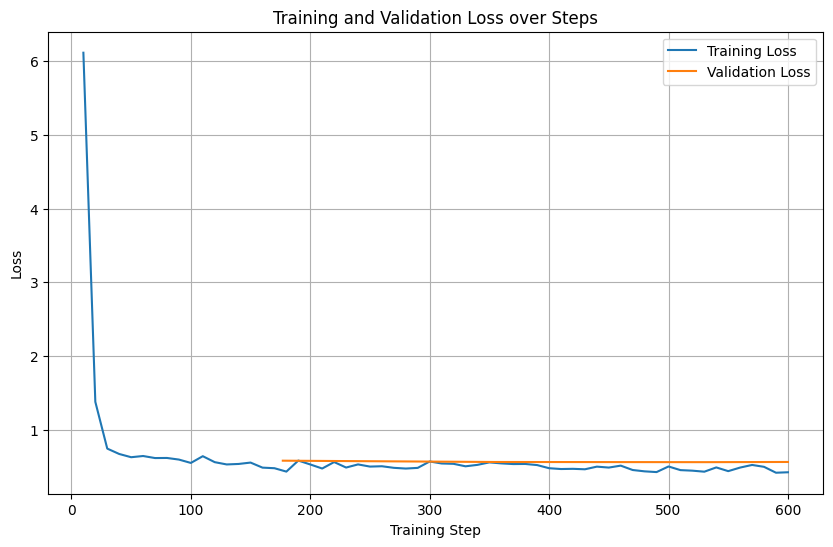


Evaluation Metrics:
preset: faster
samples: 554.0000
overall_sentiment_accuracy: 0.8303
macro_f1: 0.5540
macro_precision: 0.5854
macro_recall: 0.5322
labels: ['negative', 'neutral', 'positive', 'rising']


In [ ]:
# 10) Visualization of Training and Evaluation Results

# Load training history from trainer state
log_history = trainer.state.log_history

# Create a DataFrame for easy plotting
history_df = pd.DataFrame(log_history)

# Plot Training and Validation Loss
plt.figure(figsize=(10, 6))
sns.lineplot(data=history_df, x="step", y="loss", label="Training Loss")
sns.lineplot(data=history_df, x="step", y="eval_loss", label="Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Steps")
plt.legend()
plt.grid(True)
plt.show()

# Load evaluation metrics
try:
    with open(EVAL_RESULTS_FAST, "r") as f:
        eval_metrics = json.load(f)

    print("\nEvaluation Metrics:")
    for metric, value in eval_metrics.items():
        if isinstance(value, (int, float)):
            print(f"{metric}: {value:.4f}")
        else:
            print(f"{metric}: {value}")

except FileNotFoundError:
    print(f"Evaluation results file not found: {EVAL_RESULTS_FAST}")
except json.JSONDecodeError:
    print(f"Error decoding JSON from {EVAL_RESULTS_FAST}")


✓ Loaded baseline predictions from /content/drive/MyDrive/PropInsight/results/baseline_predictions.json
✓ Loaded finetuned evaluation results from /content/drive/MyDrive/PropInsight/results/evaluation_results_faster.json
✓ Calculated baseline metrics from predictions


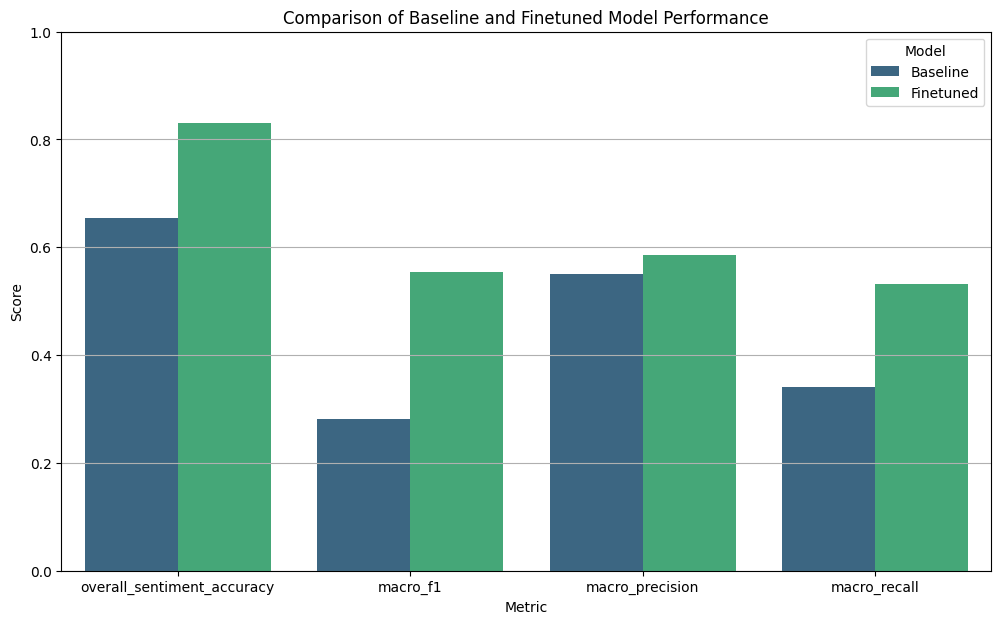

In [ ]:
# 11) Comparison with Baseline

# Load baseline evaluation results
# BASELINE_EVAL_RESULTS = RESULTS_DIR / "baseline_evaluation_results.json" # Original path

# New path for baseline predictions provided by the user
BASELINE_PREDICTIONS_FILE = RESULTS_DIR / "baseline_predictions.json"

try:
    # Load baseline predictions
    with open(BASELINE_PREDICTIONS_FILE, "r", encoding="utf-8") as f:
        baseline_preds = json.load(f)
    print(f"✓ Loaded baseline predictions from {BASELINE_PREDICTIONS_FILE}")

    # Load finetuned evaluation results (already loaded in cell 10, but reloading for clarity)
    FINETUNED_EVAL_RESULTS = EVAL_RESULTS_FAST # Use the correct variable name
    with open(FINETUNED_EVAL_RESULTS, "r") as f:
        finetuned_metrics = json.load(f)
    print(f"✓ Loaded finetuned evaluation results from {FINETUNED_EVAL_RESULTS}")

    # Calculate metrics for baseline predictions from the loaded data
    # Assuming 'test_data' is still available from previous cells
    if 'test_data' not in locals():
         raise NameError("test_data is not available. Please ensure previous cells are run.")

    y_true_baseline = [extract_field(p.get("ground_truth", ""), "Overall Sentiment") for p in baseline_preds]
    y_pred_baseline = [extract_field(p.get("prediction", ""), "Overall Sentiment") for p in baseline_preds]
    labels_baseline = sorted(list(set(y_true_baseline) | set(y_pred_baseline)))


    # Calculate metrics
    baseline_metrics = {
        "preset": "baseline",
        "samples": len(baseline_preds),
        "overall_sentiment_accuracy": float(accuracy_score(y_true_baseline, y_pred_baseline)) if len(y_true_baseline) else 0.0,
        "macro_f1": float(f1_score(y_true_baseline, y_pred_baseline, labels=labels_baseline, average="macro", zero_division=0)),
        "macro_precision": float(precision_score(y_true_baseline, y_pred_baseline, labels=labels_baseline, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true_baseline, y_pred_baseline, labels=labels_baseline, average="macro", zero_division=0)),
        "labels": labels_baseline,
    }
    print("✓ Calculated baseline metrics from predictions")


    # Prepare data for comparison plot
    metrics_to_compare = ["overall_sentiment_accuracy", "macro_f1", "macro_precision", "macro_recall"]
    comparison_data = []

    for metric in metrics_to_compare:
        comparison_data.append({
            "Metric": metric,
            "Model": "Baseline",
            "Score": baseline_metrics.get(metric, 0.0) # Use .get() with default 0.0 in case a metric is missing
        })
        comparison_data.append({
            "Metric": metric,
            "Model": "Finetuned",
            "Score": finetuned_metrics.get(metric, 0.0)
        })

    comparison_df = pd.DataFrame(comparison_data)

    # Create comparison plot
    plt.figure(figsize=(12, 7))
    sns.barplot(data=comparison_df, x="Metric", y="Score", hue="Model", palette="viridis")
    plt.ylabel("Score")
    plt.title("Comparison of Baseline and Finetuned Model Performance")
    plt.ylim(0, 1) # Assuming metrics are between 0 and 1
    plt.grid(axis='y')
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please ensure the baseline predictions file and finetuned evaluation result file exist.")
except json.JSONDecodeError:
    print(f"Error decoding JSON from one of the files.")
except NameError as e:
     print(f"Data error: {e}")
except Exception as e:
    print(f"An unexpected error occurred during comparison: {e}")

### 11a) Evaluate Baseline Model

This step will load the original pre-trained model (before fine-tuning), run inference on the test dataset, and calculate evaluation metrics.

In [ ]:
# FINETUNED EVALUATION


# The model and tokenizer are already loaded and finetuned in cell 99PTJ-x9Lcg4
# We can directly use the 'model' and 'tokenizer' variables from there.
# If you need to explicitly load the finetuned model here, you would do:
# base_model_eval = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID,
#     quantization_config=bnb_config, # Use the same quantization config as training
#     device_map="auto",
#     trust_remote_code=True
# )
# finetuned_model_eval = PeftModel.from_pretrained(base_model_eval, FINETUNED_DIR)
# finetuned_model_eval.eval()
# current_model = finetuned_model_eval
# current_tokenizer = tokenizer # Use the same tokenizer

# Using the 'model' and 'tokenizer' variables from the training cell (99PTJ-x9Lcg4)
current_model = model
current_tokenizer = tokenizer


finetuned_preds = []
for ex in tqdm(test_data, desc="Finetuned inference"):
    inp = ex['input']
    # Use the build_prompt_infer and gen_output functions defined earlier for consistency
    pred = gen_output(current_model, current_tokenizer, inp)

    # Extract domain metrics (Assuming these functions are defined elsewhere in the notebook)
    # You might need to ensure corpus_resources is accessible or pass necessary data
    # singlish_score = check_singlish_coverage(
    #     inp, pred, corpus_resources.get('singlish_lexicon')
    # )
    # entity_score = check_property_entities(
    #     inp, pred,
    #     corpus_resources.get('property_glossary'),
    #     corpus_resources.get('regex_patterns')
    # )

    finetuned_preds.append({
        "input": inp,
        "prediction": pred,
        "overall_pred": extract_field(pred, "Overall Sentiment"), # Use extract_field defined earlier
        "ground_truth": ex.get("output", ""),
        # "singlish_score": singlish_score, # Uncomment if domain metrics are needed and functions are available
        # "entity_score": entity_score,     # Uncomment if domain metrics are needed and functions are available
    })

# Clean up model if it was loaded specifically for this cell
# if 'finetuned_model_eval' in locals():
#     del finetuned_model_eval, base_model_eval
#     torch.cuda.empty_cache()

# Make sure the RESULTS_DIR and VISUALIZATIONS_DIR are accessible
RESULTS_D2 = RESULTS_DIR # Assuming RESULTS_D2 is meant to be RESULTS_DIR
VIS_D2 = VISUALIZATIONS_DIR # Assuming VIS_D2 is meant to be VISUALIZATIONS_DIR

json.dump(finetuned_preds, open(RESULTS_D2 / "finetuned_predictions.json", "w"), indent=2)

y_true_ft = [extract_field(ex["ground_truth"], "Overall Sentiment") for ex in finetuned_preds] # Extract from ground_truth in finetuned_preds
y_pred_ft = [p["overall_pred"] for p in finetuned_preds]
labels_ft = sorted(list(set(y_true_ft) | set(y_pred_ft))) # Use list() to avoid issues with set ordering

# Standard metrics
finetuned_metrics = {
    "overall_sentiment_accuracy": float(accuracy_score(y_true_ft, y_pred_ft)),
    "macro_precision": float(precision_score(y_true_ft, y_pred_ft, labels=labels_ft, average='macro', zero_division=0)),
    "macro_recall": float(recall_score(y_true_ft, y_pred_ft, labels=labels_ft, average='macro', zero_division=0)),
    "macro_f1": float(f1_score(y_true_ft, y_pred_ft, labels=labels_ft, average='macro', zero_division=0)),
    "weighted_f1": float(f1_score(y_true_ft, y_pred_ft, labels=labels_ft, average='weighted', zero_division=0)),
}

# Domain-specific metrics (Uncomment and adapt if needed)
# singlish_scores = [p.get('singlish_score', 0.0) for p in finetuned_preds]
# entity_scores = [p.get('entity_score', 0.0) for p in finetuned_preds]

# finetuned_metrics.update({
#     "singlish_coverage": float(np.mean(singlish_scores)) if singlish_scores else 0.0,
#     "entity_recognition": float(np.mean(entity_scores)) if entity_scores else 0.0,
# })
# finetuned_metrics["domain_avg"] = (
#     finetuned_metrics.get("singlish_coverage", 0.0) + finetuned_metrics.get("entity_recognition", 0.0)
# ) / 2.0


# BLEU & ROUGE (with error handling)
try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from rouge_score import rouge_scorer
    import nltk
    # nltk.download('punkt', quiet=True) # Only download if not already done
    from nltk.tokenize import word_tokenize

    rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    bleu_scores, rouge1_scores, rouge2_scores, rougeL_scores = [], [], [], []
    smoothing = SmoothingFunction().method1

    for pred_item in finetuned_preds: # Iterate through the list of prediction dictionaries
        gt = pred_item['ground_truth']
        pr = pred_item['prediction']

        if gt and pr and isinstance(gt, str) and isinstance(pr, str): # Add type checks
            try:
                # BLEU
                reference = [word_tokenize(gt.lower())]
                hypothesis = word_tokenize(pr.lower())
                if len(hypothesis) > 0: # Avoid division by zero in BLEU calculation
                     bleu = sentence_bleu(reference, hypothesis, smoothing_function=smoothing)
                     bleu_scores.append(bleu)
                else:
                    bleu_scores.append(0)


                # ROUGE
                rouge_result = rouge_scorer_obj.score(gt, pr)
                rouge1_scores.append(rouge_result['rouge1'].fmeasure)
                rouge2_scores.append(rouge_result['rouge2'].fmeasure)
                rougeL_scores.append(rouge_result['rougeL'].fmeasure)
            except Exception as e: # Catch specific exceptions if possible, or general Exception
                print(f"Error calculating NLP metrics for one sample: {e}")
                bleu_scores.append(0)
                rouge1_scores.append(0)
                rouge2_scores.append(0)
                rougeL_scores.append(0)
        else:
            # Handle cases where ground truth or prediction is empty or not a string
            bleu_scores.append(0)
            rouge1_scores.append(0)
            rouge2_scores.append(0)
            rougeL_scores.append(0)


    # Add to metrics
    finetuned_metrics.update({
        "bleu_score": float(np.mean(bleu_scores)) if bleu_scores else 0.0,
        "rouge1_score": float(np.mean(rouge1_scores)) if rouge1_scores else 0.0,
        "rouge2_score": float(np.mean(rouge2_scores)) if rouge2_scores else 0.0,
        "rougeL_score": float(np.mean(rougeL_scores)) if rougeL_scores else 0.0,
        "labels": labels_ft,
    })
except ImportError:
    print("⚠️  NLTK/ROUGE packages not available. Skipping NLP metrics.")
    finetuned_metrics["labels"] = labels_ft
except Exception as e:
    print(f"An error occurred during NLP metric calculation: {e}")
    finetuned_metrics["labels"] = labels_ft


# Calculate per-label F1 scores
per_label_f1 = {}
for label in labels_ft:
    # Filter true and predicted labels for the current label
    y_true_label = [1 if yt == label else 0 for yt in y_true_ft]
    y_pred_label = [1 if yp == label else 0 for yp in y_pred_ft]

    # Calculate F1 for the current label
    # Use average='binary' for single-label F1 calculation
    # Ensure there are samples for this label in y_true_label
    if sum(y_true_label) > 0 or sum(y_pred_label) > 0:
        try:
            label_f1 = f1_score(
                y_true_label,
                y_pred_label,
                average='binary',
                zero_division=0,
                pos_label=1 # Specify positive label for binary calculation
            )
            per_label_f1[label] = float(label_f1)
        except Exception as e:
             print(f"Error calculating F1 for label '{label}': {e}")
             per_label_f1[label] = 0.0
    else:
        per_label_f1[label] = 0.0 # No samples for this label


finetuned_metrics['per_label_f1'] = per_label_f1

json.dump(finetuned_metrics, open(RESULTS_D2 / "finetuned_metrics.json", "w"), indent=2)

# ========== NLP METRICS VISUALIZATION ==========
# Ensure plotting functions are defined elsewhere or included
# Example placeholders if they are not:
def plot_sentiment_distribution(y_true, y_pred, title, save_path, colors):
    print(f"Placeholder for plot_sentiment_distribution: {title}")
    # Add actual plotting code here if needed
    pass

def plot_confusion_matrix(y_true, y_pred, labels, title, save_path, cmap):
    print(f"Placeholder for plot_confusion_matrix: {title}")
    # Add actual plotting code here if needed
    pass


if 'bleu_score' in finetuned_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: NLP Metrics Bar Chart
    nlp_metrics = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
    nlp_values = [
        finetuned_metrics.get('bleu_score', 0.0),
        finetuned_metrics.get('rouge1_score', 0.0),
        finetuned_metrics.get('rouge2_score', 0.0),
        finetuned_metrics.get('rougeL_score', 0.0)
    ]

    bars = axes[0].bar(nlp_metrics, nlp_values, color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'],
                      alpha=0.8, edgecolor='black', linewidth=1.2)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('NLP Generation Metrics (Finetuned Model)', fontsize=13, fontweight='bold', pad=10)
    axes[0].set_ylim(0, 1.1)
    axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # Right: Per-Label F1 Scores
    if per_label_f1:
        # Sort labels by F1 score and take top 15
        sorted_labels = sorted(per_label_f1.items(), key=lambda x: x[1], reverse=True)[:15]
        label_names = [l[0] for l in sorted_labels]
        label_f1s = [l[1] for l in sorted_labels]

        bars = axes[1].barh(label_names, label_f1s, color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1)
        for i, (bar, val) in enumerate(zip(bars, label_f1s)):
            axes[1].text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

        axes[1].set_xlabel('F1 Score', fontsize=12, fontweight='bold')
        axes[1].set_title('Per-Sentiment F1 Scores (Top 15)', fontsize=13, fontweight='bold', pad=10)
        axes[1].set_xlim(0, 1.1)
        axes[1].grid(True, alpha=0.3, axis='x', linestyle='--')
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)
    else:
        axes[1].text(0.5, 0.5, "No per-label data", ha='center', va='center', fontsize=12)
        axes[1].set_title('Per-Sentiment F1 Scores', fontsize=13, fontweight='bold')
        axes[1].axis('off')

    plt.tight_layout()
    # plt.savefig(VIS_D2 / "nlp_metrics.png", dpi=300, bbox_inches='tight') # Uncomment if you want to save
    plt.show() # Display the plot


# Call plotting functions for sentiment distribution and confusion matrix if they are defined
# plot_sentiment_distribution(y_true_ft, y_pred_ft,
#                            "Overall Sentiment Distribution — Finetuned (Danube2)",
#                            VIS_D2 / "finetuned_sentiment_comparison.png",
#                            colors=['#3498db', '#27ae60'])

# plot_confusion_matrix(y_true_ft, y_pred_ft, labels_ft,
#                      "Finetuned Confusion Matrix (Danube2)",
#                      VIS_D2 / "finetuned_confusion_matrix.png",
#                      cmap='Greens')


Finetuned inference:   0%|          | 0/554 [00:00<?, ?it/s]